# Q3 — Is inconsistency linked to data-quality issues?

Relates disagreement to **review volume** and **platform coverage**, reporting the
mandatory *correlation between review count and rating variance*. Everything is split by
2- vs 3-platform coverage, since a 3-platform max−min range is mechanically wider than a
2-platform one — pooling them would confound the two.

> **Timeliness limitation.** "Outdated information" cannot be measured from ClickHouse:
> there is no per-record collection timestamp (`updated_at` is load time, identical across
> rows). We answer the data-quality link with review-volume and coverage proxies and flag
> timeliness as out of reach for this schema.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
q3_corr = publish(run(queries.q3_correlations()), "q3_correlations",
                  "Q3 — Correlation of rating spread with review volume, by coverage.")
q3_corr

,coverage,venues,corr_range_least_reviews,corr_range_total_reviews
0,,4070,-0.128,-0.073
1,2,3341,-0.137,-0.099
2,3,729,-0.049,-0.015


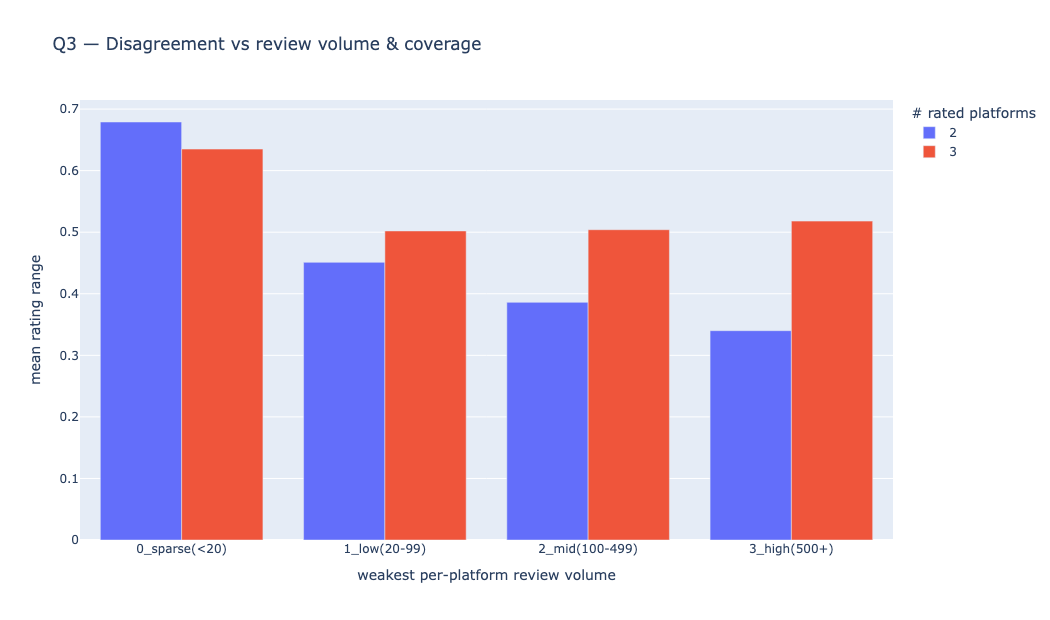

,coverage,min_reviews_bucket,restaurants,mean_range
0,2,0_sparse(<20),1362,0.679
1,2,1_low(20-99),766,0.451
2,2,2_mid(100-499),782,0.386
3,2,3_high(500+),431,0.340
4,3,0_sparse(<20),171,0.635
5,3,1_low(20-99),213,0.502
6,3,2_mid(100-499),220,0.504
7,3,3_high(500+),125,0.518


In [3]:
q3_bin = publish(run(queries.q3_binned()), "q3_disagreement_by_reviews",
                 "Q3 — Mean rating spread by weakest-review bucket and coverage.")
fig = px.bar(q3_bin, x="min_reviews_bucket", y="mean_range", color="coverage", barmode="group",
             labels={"min_reviews_bucket": "weakest per-platform review volume",
                     "mean_range": "mean rating range", "coverage": "# rated platforms"},
             title="Q3 — Disagreement vs review volume & coverage")
fig.show()
q3_bin

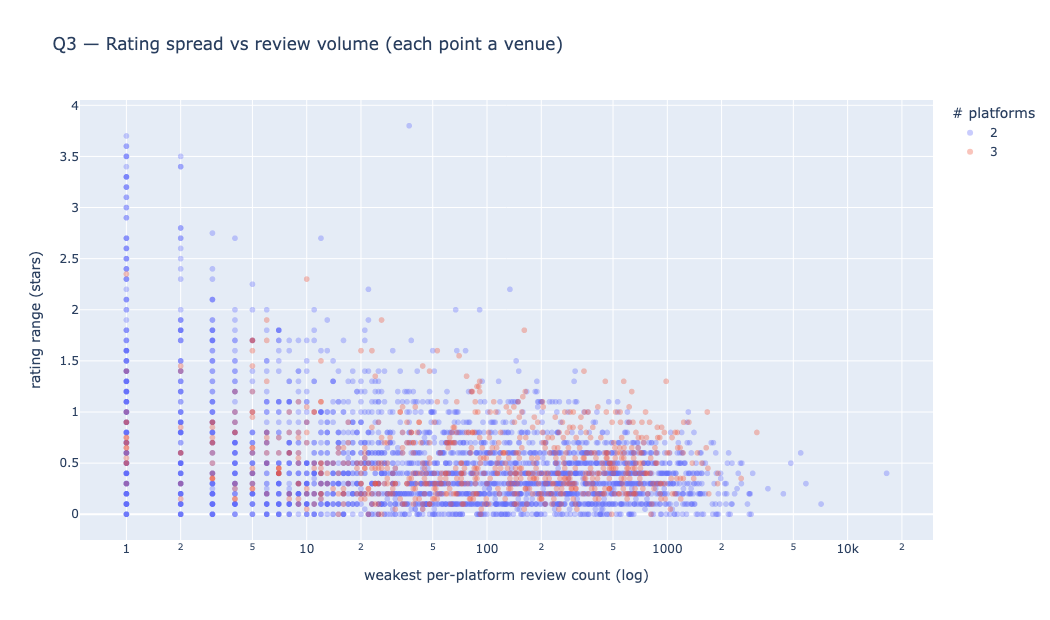

In [4]:
scatter = run(queries.q3_scatter_rows())
fig = px.scatter(scatter, x="least_reviews", y="rating_range_5", color="coverage",
                 opacity=0.35, log_x=True,
                 labels={"least_reviews": "weakest per-platform review count (log)",
                         "rating_range_5": "rating range (stars)", "coverage": "# platforms"},
                 title="Q3 — Rating spread vs review volume (each point a venue)")
fig.show()

**Answer (Q3):** The correlation between rating spread and review volume is **negative
but weak** (`q3_correlations`): venues whose weakest platform has few reviews disagree
somewhat more, so inconsistency is *partly* a data-quality artefact — but review volume is
far from the whole story. The effect is clearer for 2-platform venues than 3-platform ones.
Timeliness is not assessable from the current schema (noted above).